# 06 — LightGBM Purchase Prediction

**Goal:** beat the Random Forest PR-AUC baseline (0.639) using a LightGBM binary classifier.

| Model               | PR-AUC (test) | CV               |
|---------------------|---------------|------------------|
| Logistic Regression | 0.357         | 0.338 ± 0.002    |
| Random Forest       | 0.639         | 0.624 ± 0.005    |
| **LightGBM target** | **> 0.639**   |                  |

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
)

sns.set_theme(style='whitegrid')

DATA_DIR   = os.path.join('..', 'data')
MODELS_DIR = os.path.join('..', 'models')

## 1 — Load data

In [2]:
sessions = pd.read_parquet(os.path.join(DATA_DIR, 'sessions_features.parquet'))

# Drop pre-computed behavioral_state columns — we will refit K-Means on the
# training set only (see leakage note below) and assign fresh labels.
for col in ['behavioral_state', 'behavioral_state_label']:
    if col in sessions.columns:
        sessions = sessions.drop(columns=[col])

print(f'Shape: {sessions.shape}')
print(f'Columns: {sessions.columns.tolist()}')
print(f'Purchase rate: {sessions["purchased"].mean():.4%}')

Shape: (1761675, 17)
Columns: ['session_id', 'visitorid', 'n_views', 'n_addtocart', 'n_items', 'duration_sec', 'purchased', 'n_revisited_items', 'hour_of_day', 'day_of_week', 'view_to_cart_ratio', 'is_first_session', 'time_to_first_cart_sec', 'has_cart', 'last_event_type', 'cart_then_view_count', 'n_sessions_visitor']
Purchase rate: 0.8116%


## 2 — Feature engineering

### 2a. Derive `last_event_is_cart`

In [3]:
if 'last_event_type' in sessions.columns:
    # event type 1 = addtocart in the Retailrocket dataset
    sessions['last_event_is_cart'] = (sessions['last_event_type'] == 1).astype(int)
    print(f'last_event_is_cart created — cart-ending sessions: {sessions["last_event_is_cart"].mean():.2%}')
else:
    print('last_event_type not found — last_event_is_cart will be skipped')

last_event_is_cart created — cart-ending sessions: 1.11%


### 2b. Train / test split

> **Note — no temporal split available:** The parquet does not contain a session timestamp
> column (`session_start`, `first_event_time`, etc.), so a chronological 80/20 split is not
> possible. We use a stratified random split (same approach as notebook 03) to preserve the
> 1:122 class ratio in both partitions. This means the evaluation cannot account for any
> temporal drift in user behaviour.

In [4]:
TARGET = 'purchased'

train, test = train_test_split(
    sessions,
    test_size=0.2,
    random_state=42,
    stratify=sessions[TARGET],
)

print(f'Train: {len(train):,}  |  Test: {len(test):,}')
print(f'Train purchase rate: {train[TARGET].mean():.4%}')
print(f'Test  purchase rate: {test[TARGET].mean():.4%}')

Train: 1,409,340  |  Test: 352,335
Train purchase rate: 0.8116%
Test  purchase rate: 0.8114%


## 3 — K-Means behavioral state pipeline (train-only fit)

> **Leakage note:** K-Means is fitted exclusively on the training set.
> `km.predict()` is then applied separately to train and test so the cluster
> centroids have seen no test data.

In [5]:
BEHAVIORAL   = ['n_views', 'n_addtocart', 'n_items', 'n_revisited_items',
                 'duration_sec', 'view_to_cart_ratio', 'is_first_session']
LOG_FEATURES = ['n_views', 'n_addtocart', 'n_items', 'n_revisited_items', 'duration_sec']

# --- fit scaler and KMeans on training data only ---
X_km_train = train[BEHAVIORAL].copy()
X_km_train[LOG_FEATURES] = np.log1p(X_km_train[LOG_FEATURES])

scaler = StandardScaler()
X_km_train_scaled = scaler.fit_transform(X_km_train)

km = KMeans(n_clusters=5, random_state=42, n_init=10)
train_labels = km.fit_predict(X_km_train_scaled)

# --- assign stable names by purchase rate (rank 1 = lowest = 'bounce') ---
tmp = train.copy()
tmp['_label'] = train_labels
rank = (
    tmp.groupby('_label')[TARGET].mean()
    .rank(method='first').astype(int)
)
name_map = {
    int(k): ['bounce', 'light_browser', 'returning_bounce', 'deep_browser', 'cart_adder'][v - 1]
    for k, v in rank.items()
}
print('Cluster → name map:', name_map)

CAT_DTYPE = pd.CategoricalDtype(
    categories=['bounce', 'light_browser', 'returning_bounce', 'deep_browser', 'cart_adder']
)

train = train.copy()
train['behavioral_state'] = pd.Categorical(
    [name_map[l] for l in train_labels], dtype=CAT_DTYPE
)

# --- apply to test ---
X_km_test = test[BEHAVIORAL].copy()
X_km_test[LOG_FEATURES] = np.log1p(X_km_test[LOG_FEATURES])
X_km_test_scaled = scaler.transform(X_km_test)
test_labels = km.predict(X_km_test_scaled)

test = test.copy()
test['behavioral_state'] = pd.Categorical(
    [name_map[l] for l in test_labels], dtype=CAT_DTYPE
)

Cluster → name map: {0: 'bounce', 1: 'deep_browser', 2: 'cart_adder', 3: 'returning_bounce', 4: 'light_browser'}


In [6]:
# Verify the purchase-rate gradient is correct (bounce < ... < cart_adder)
state_stats = (
    train.groupby('behavioral_state', observed=False)[TARGET]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'purchase_rate', 'count': 'n_sessions'})
    .sort_values('purchase_rate')
)
state_stats['purchase_rate'] = state_stats['purchase_rate'].map('{:.4%}'.format)
print(state_stats)

                 purchase_rate  n_sessions
behavioral_state                          
bounce                 0.0599%      903670
light_browser          0.3284%      220167
returning_bounce       0.4622%      208565
deep_browser           3.1431%       48964
cart_adder            27.4219%       27974


## 4 — Final feature set

In [7]:
FEATURES = [
    # Core signal
    'n_addtocart',        # r=0.337, perm_imp=0.224 — strongest intent signal
    'duration_sec',       # r=0.294, perm_imp=0.618 — dominant (circularity caveat)
    'view_to_cart_ratio', # r=0.281, perm_imp=0.027 — decisiveness proxy
    'n_views',            # r=0.182, perm_imp=0.022 — engagement depth
    'n_revisited_items',  # r=0.176, perm_imp=0.006 — focused re-engagement
    'n_items',            # r=0.172, perm_imp=0.004 — breadth (marginal)
    'is_first_session',   # r=-0.062, perm_imp=0.015 — returning visitor signal
    'hour_of_day',        # r=0.012, perm_imp=0.003 — weak, keep for SHAP check

    # Categorical (from K-Means)
    'behavioral_state',   # label from K-Means — passed as categorical to LightGBM
]

# Add if available
if 'last_event_is_cart' in train.columns:
    FEATURES.append('last_event_is_cart')

# Explicitly dropped:
#   day_of_week          — perm_imp=0.000, confirmed useless
#   has_cart             — fully redundant with n_addtocart > 0
#   cart_then_view_count — 98.8% zero, redundant
#   n_sessions_visitor   — low signal, cold-start problem

print('Features:', FEATURES)

cat_col = ['behavioral_state'] if 'behavioral_state' in FEATURES else []

X_train = train[FEATURES]
X_test  = test[FEATURES]
y_train = train[TARGET]
y_test  = test[TARGET]

print(f'\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}')
IMBALANCE_RATIO = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'Imbalance ratio: {IMBALANCE_RATIO}:1')

Features: ['n_addtocart', 'duration_sec', 'view_to_cart_ratio', 'n_views', 'n_revisited_items', 'n_items', 'is_first_session', 'hour_of_day', 'behavioral_state', 'last_event_is_cart']

Train: 1,409,340  |  Test: 352,335
Imbalance ratio: 122:1


## 5 — LightGBM training

### 5a. Model configuration

In [8]:
params = {
    'objective':        'binary',
    'metric':           'average_precision',
    'scale_pos_weight': IMBALANCE_RATIO,
    'num_leaves':       127,
    'min_child_samples': 200,
    'learning_rate':    0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'verbose':          -1,
    'random_state':     42,
}

### 5b. Fit with early stopping on a validation slice

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

model = lgb.LGBMClassifier(**params, n_estimators=2000)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(100),
    ],
    categorical_feature=cat_col,
)
print(f'Best iteration: {model.best_iteration_}')

Training until validation scores don't improve for 50 rounds


[100]	valid_0's average_precision: 0.783038


[200]	valid_0's average_precision: 0.794857


Early stopping, best iteration is:
[177]	valid_0's average_precision: 0.796585
Best iteration: 177


### 5c. 5-fold cross-validation on full training set

In [10]:
cv_model = lgb.LGBMClassifier(**params, n_estimators=model.best_iteration_)
cv_scores = cross_val_score(
    cv_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=-1,
)
print(f'CV PR-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

CV PR-AUC: 0.813 ± 0.004


## 6 — Evaluation

### 6a. PR-AUC and ROC-AUC on test set

In [11]:
y_proba = model.predict_proba(X_test, categorical_feature=cat_col)[:, 1]

pr_auc  = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'PR-AUC  (test): {pr_auc:.3f}  |  Baselines — LR: 0.357  RF: 0.639')
print(f'ROC-AUC (test): {roc_auc:.3f}  (inflated at 1:{IMBALANCE_RATIO} imbalance)')

PR-AUC  (test): 0.823  |  Baselines — LR: 0.357  RF: 0.639
ROC-AUC (test): 0.995  (inflated at 1:122 imbalance)


### 6b. Precision-Recall curve

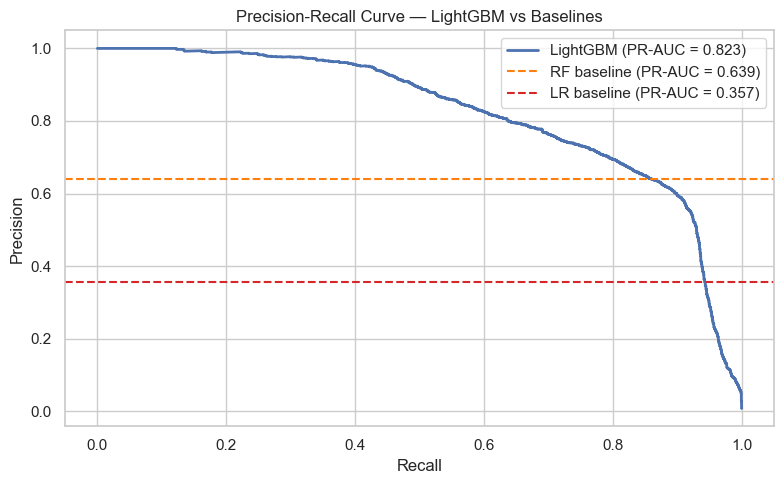

In [12]:
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_arr, precision_arr, label=f'LightGBM (PR-AUC = {pr_auc:.3f})', lw=2)
ax.axhline(0.639, color='tab:orange', ls='--', label='RF baseline (PR-AUC = 0.639)')
ax.axhline(0.357, color='tab:red',    ls='--', label='LR baseline (PR-AUC = 0.357)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — LightGBM vs Baselines')
ax.legend()
plt.tight_layout()
plt.show()

### 6c. Threshold analysis

> **Note:** With 1:122 imbalance the F1-optimal threshold is expected to be very high (>0.95).
> Both the F1-optimal and the business threshold (precision ≥ 0.70) are reported below.

In [13]:
f1 = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)

f1_opt_idx = f1.argmax()
prec70_idx = next((i for i, p in enumerate(precision_arr) if p >= 0.70), None)

print(
    f'F1-optimal threshold:  {thresholds[f1_opt_idx]:.4f}  '
    f'→  precision {precision_arr[f1_opt_idx]:.2f}  '
    f'recall {recall_arr[f1_opt_idx]:.2f}  '
    f'F1 {f1[f1_opt_idx]:.3f}'
)
if prec70_idx is not None and prec70_idx < len(thresholds):
    print(
        f'Precision≥0.70 threshold: {thresholds[prec70_idx]:.4f}  '
        f'→  recall {recall_arr[prec70_idx]:.2f}'
    )

F1-optimal threshold:  0.9862  →  precision 0.70  recall 0.79  F1 0.745
Precision≥0.70 threshold: 0.9860  →  recall 0.79


### 6d. Confusion matrix at F1-optimal threshold

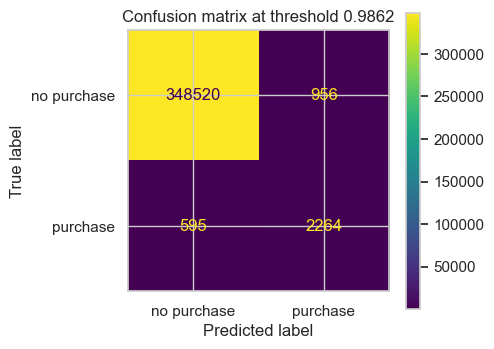

In [14]:
threshold = thresholds[f1_opt_idx]
y_pred = (y_proba >= threshold).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['no purchase', 'purchase'],
).plot(ax=ax)
ax.set_title(f'Confusion matrix at threshold {threshold:.4f}')
plt.tight_layout()
plt.show()

### 6e. Model comparison

              Model   PR-AUC            CV
     Random (floor) 0.008000             —
Logistic Regression 0.357000 0.338 ± 0.002
      Random Forest 0.639000 0.624 ± 0.005
           LightGBM 0.822553 0.813 ± 0.004


/var/folders/rj/nznt027d1y56h7758x0ct24h0000gn/T/ipykernel_57015/893753831.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


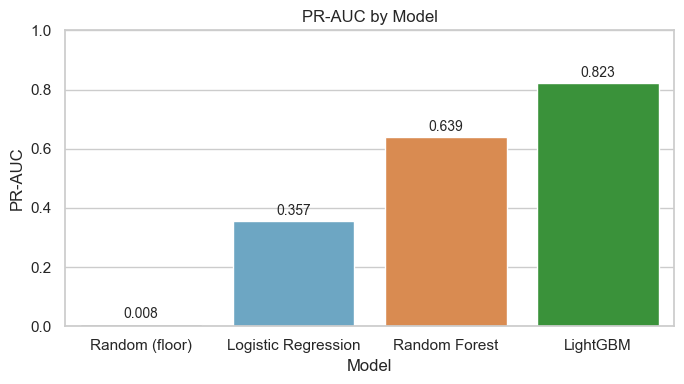

In [15]:
results = pd.DataFrame({
    'Model':  ['Random (floor)', 'Logistic Regression', 'Random Forest', 'LightGBM'],
    'PR-AUC': [0.008, 0.357, 0.639, pr_auc],
    'CV':     ['—', '0.338 ± 0.002', '0.624 ± 0.005',
                f'{cv_scores.mean():.3f} ± {cv_scores.std():.3f}'],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
palette = ['#aaaaaa', '#5faad1', '#f0873a', '#2ca02c']
sns.barplot(
    data=results,
    x='Model',
    y='PR-AUC',
    palette=palette,
    ax=ax,
)
ax.set_title('PR-AUC by Model')
ax.set_ylim(0, 1)
for bar, val in zip(ax.patches, results['PR-AUC']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=10,
    )
plt.tight_layout()
plt.show()

## 7 — SHAP Analysis

### 7a. Compute SHAP values

In [16]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification LightGBM returns a list [neg_class, pos_class]
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')

SHAP values shape: (352335, 10)


/Users/helena.schulz.ext/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### 7b. Global feature importance (mean |SHAP|)

RF permutation importance for reference:
`duration_sec` 0.618 · `n_addtocart` 0.224 · `view_to_cart_ratio` 0.027 · `n_views` 0.022 · `is_first_session` 0.015 · `n_revisited_items` 0.006

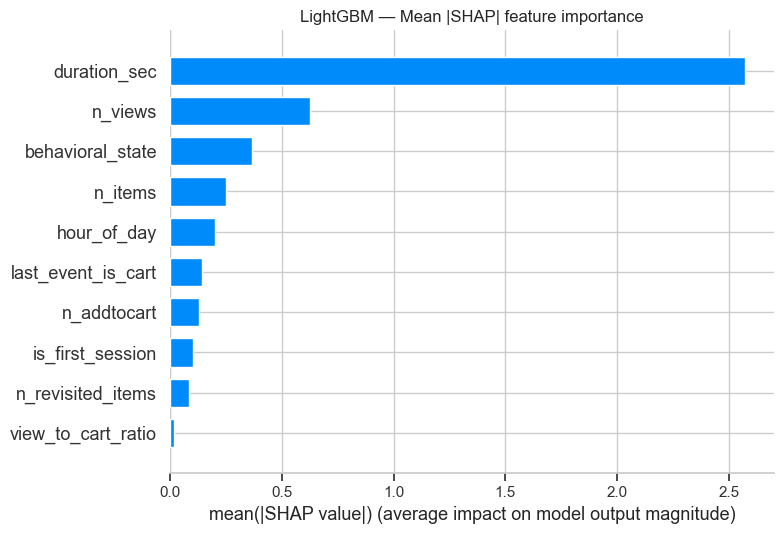

In [17]:
shap.summary_plot(
    sv, X_test,
    plot_type='bar',
    show=False,
)
plt.title('LightGBM — Mean |SHAP| feature importance')
plt.tight_layout()
plt.show()

### 7c. Beeswarm plot

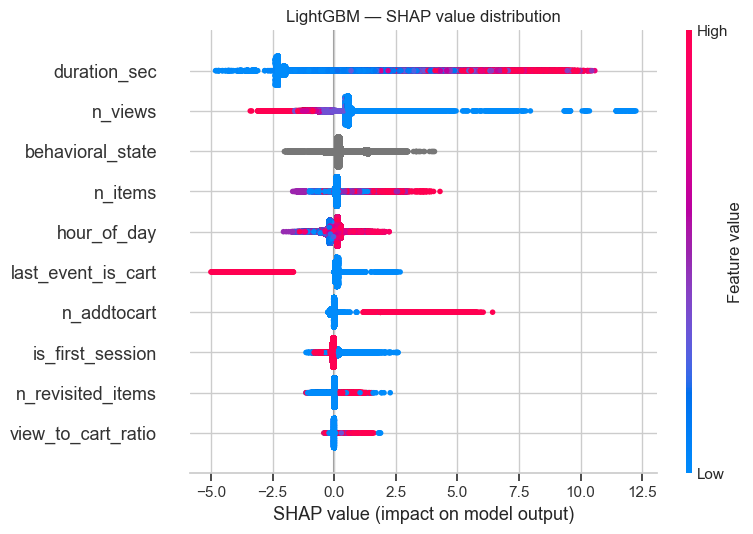

In [18]:
shap.summary_plot(sv, X_test, show=False)
plt.title('LightGBM — SHAP value distribution')
plt.tight_layout()
plt.show()

### 7d. Force plots — 3 example sessions


--- cart_adder — purchased ---
n_addtocart                    1
duration_sec            2151.273
view_to_cart_ratio           1.0
n_views                        1
n_revisited_items              0
n_items                        1
is_first_session               1
hour_of_day                   19
behavioral_state      cart_adder
last_event_is_cart             0
Name: 315804, dtype: object
Predicted probability: 0.9993


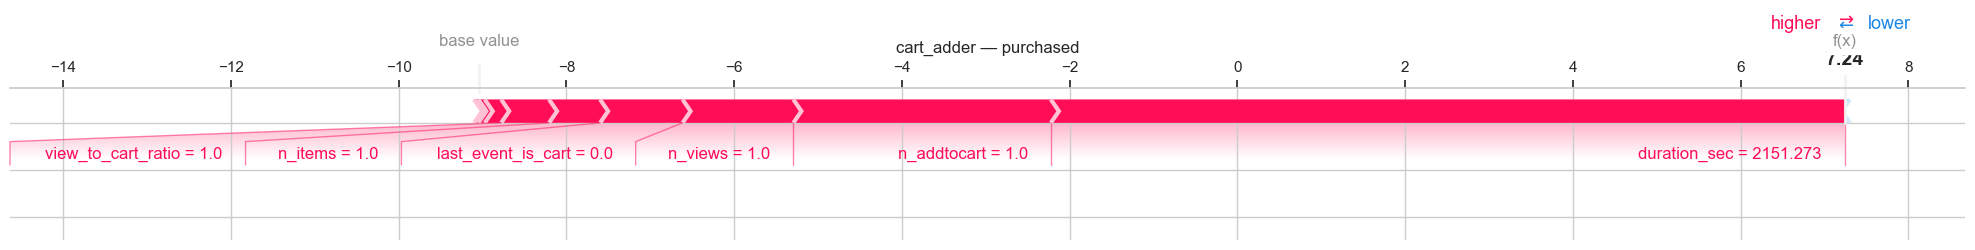


--- deep_browser — not bought ---
n_addtocart                      0
duration_sec               414.088
view_to_cart_ratio             0.0
n_views                          8
n_revisited_items                2
n_items                          4
is_first_session                 1
hour_of_day                     17
behavioral_state      deep_browser
last_event_is_cart               0
Name: 1153076, dtype: object
Predicted probability: 0.0002


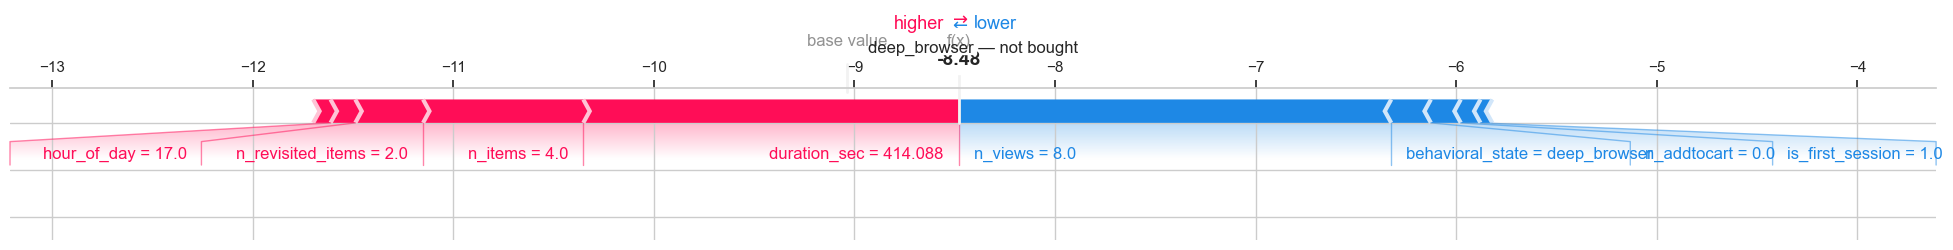


--- bounce — not bought ---
n_addtocart                0
duration_sec             0.0
view_to_cart_ratio       0.0
n_views                    1
n_revisited_items          0
n_items                    1
is_first_session           1
hour_of_day               21
behavioral_state      bounce
last_event_is_cart         0
Name: 80919, dtype: object
Predicted probability: 0.0000


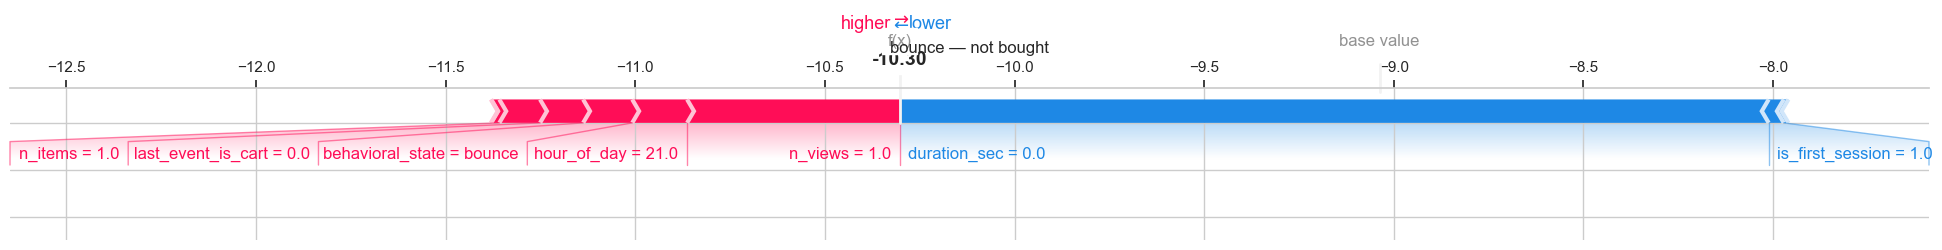

In [19]:
expected_val = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

for label, mask in [
    ('cart_adder — purchased',    (X_test['behavioral_state'] == 'cart_adder')   & (y_test == 1)),
    ('deep_browser — not bought', (X_test['behavioral_state'] == 'deep_browser') & (y_test == 0)),
    ('bounce — not bought',       (X_test['behavioral_state'] == 'bounce')       & (y_test == 0)),
]:
    candidates = X_test[mask]
    if len(candidates) == 0:
        print(f'No example found for: {label}')
        continue
    idx = candidates.index[0]
    loc = X_test.index.get_loc(idx)
    print(f'\n--- {label} ---')
    print(X_test.iloc[loc])
    print(f'Predicted probability: {y_proba[loc]:.4f}')
    shap.force_plot(
        expected_val,
        sv[loc],
        X_test.iloc[loc],
        matplotlib=True,
        show=False,
    )
    plt.title(label)
    plt.tight_layout()
    plt.show()

### 7e. `duration_sec` interaction plots — circularity check

> **Circularity caveat:** sessions that include a purchase event are longer because the
> checkout flow itself adds time. This inflates `duration_sec`'s importance. The SHAP
> dependence plot below examines whether `duration_sec` interacts with `n_addtocart`
> (intent-driven) or merely proxies session length. Despite the circularity, `duration_sec`
> is retained: its permutation importance of 0.618 in the RF model is too high to discard.

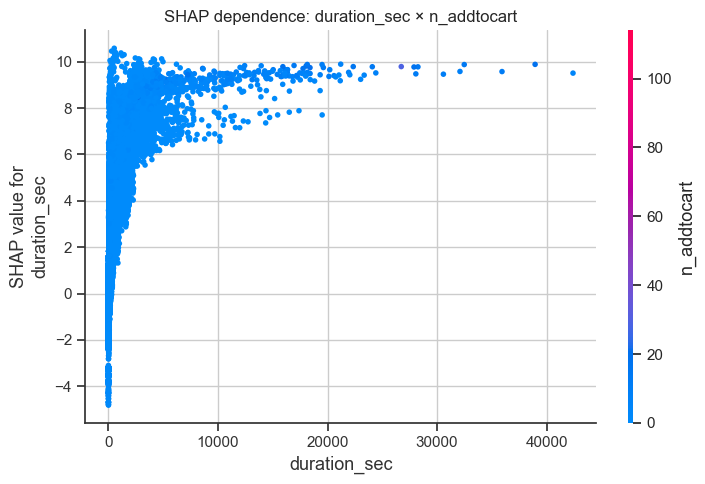

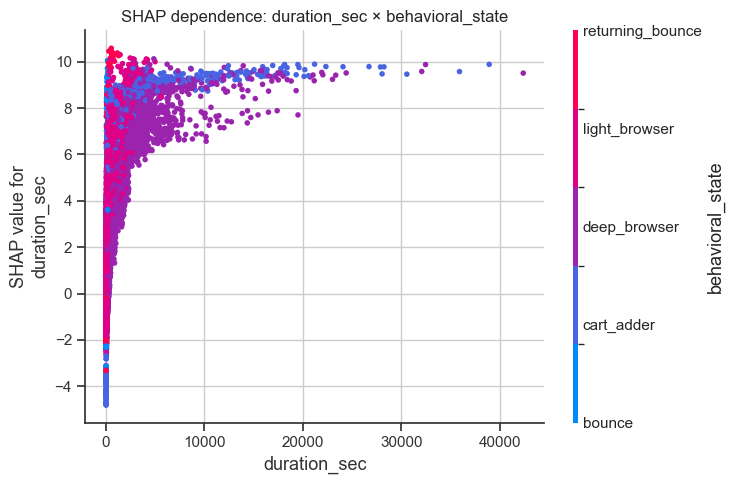

In [20]:
shap.dependence_plot('duration_sec', sv, X_test,
                     interaction_index='n_addtocart', show=False)
plt.title('SHAP dependence: duration_sec × n_addtocart')
plt.tight_layout()
plt.show()

shap.dependence_plot('duration_sec', sv, X_test,
                     interaction_index='behavioral_state', show=False)
plt.title('SHAP dependence: duration_sec × behavioral_state')
plt.tight_layout()
plt.show()

## 8 — Save artifacts

In [21]:
os.makedirs(MODELS_DIR, exist_ok=True)

model.booster_.save_model(os.path.join(MODELS_DIR, 'lgbm_purchase.txt'))
joblib.dump(km,       os.path.join(MODELS_DIR, 'kmeans_k5.pkl'))
joblib.dump(scaler,   os.path.join(MODELS_DIR, 'kmeans_scaler.pkl'))
joblib.dump(name_map, os.path.join(MODELS_DIR, 'cluster_name_map.pkl'))

meta = {
    'features':         FEATURES,
    'categorical':      cat_col,
    'best_iteration':   model.best_iteration_,
    'threshold_f1':     float(thresholds[f1_opt_idx]),
    'pr_auc_test':      float(pr_auc),
    'cv_mean':          float(cv_scores.mean()),
    'cv_std':           float(cv_scores.std()),
    'scale_pos_weight': IMBALANCE_RATIO,
}
with open(os.path.join(MODELS_DIR, 'lgbm_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:', sorted(os.listdir(MODELS_DIR)))

Saved: ['cluster_name_map.pkl', 'kmeans_k5.pkl', 'kmeans_scaler.pkl', 'lgbm_meta.json', 'lgbm_purchase.txt']
